# Exploratory Data Analysis of the Pfam Dataset
We start by loading in and inspecting the train set of the random split. 

In [ ]:
import pandas as pd
import os 
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

train_folder = "../data/random_split/train"
chunk_names = os.listdir("../data/random_split/train")
df = pd.concat([pd.read_csv(f"{train_folder}/{name}") for name in chunk_names])

In [33]:
df["accession_no"] = [val.split(".")[0][2:] for val in df["family_accession"].values]
df.sort_values(by="accession_no", inplace=True)

In [34]:
df.describe()

,family_id,sequence_name,family_accession,aligned_sequence,sequence,accession_no
count,1086741,1086741,1086741,1086741,1086741,1086741
unique,17929,1086741,17929,1086326,1086315,17929
top,Methyltransf_25,A0A1R3U1E1_9RHIZ/1-197,PF13649.6,GLFRF..SL..........S....D.F...C.N...........K....,GLFRFSLSDFCNKSVNHICGSVDDEANVWHSRLCHINFGLMSRLSS...,13649
freq,3637,1,3637,31,32,3637


From the count field we can see that there are no missing values in the dataset. Interestingly, the number of unique sequences is not the same as the total number of sequences.
## Investigating Duplicates

In [35]:
# assert df["sequence"].duplicated().sum() == 0, "There are duplicated rows."
dup_sequences = df.duplicated(subset=['sequence'],keep=False)
dup_sequences_and_labels = df.duplicated(subset=['sequence','accession_no'], keep=False)
dup_sequences_and_aligned = df.duplicated(subset=['sequence','aligned_sequence'], keep=False)
print(f"Duplicated sequences, {dup_sequences.sum()}")
print(f"Duplicated sequences and labels, {dup_sequences_and_labels.sum()}")
print(f"Duplicated sequences and aligned sequences, {dup_sequences_and_aligned.sum()}")
df[dup_sequences].describe()

Duplicated sequences, 659
Duplicated sequences and labels, 655
Duplicated sequences and aligned sequences, 641


,family_id,sequence_name,family_accession,aligned_sequence,sequence,accession_no
count,659,659,659,659,659,659
unique,65,659,65,244,233,65
top,gag_pre-integrs,R9IG83_9FIRM/531-614,PF13976.6,GLFRF..SL..........S....D.F...C.N...........K....,GLFRFSLSDFCNKSVNHICGSVDDEANVWHSRLCHINFGLMSRLSS...,13976
freq,244,1,244,31,32,244


So there are 4 duplicated sequences with different labels, and 18 duplicates with different alignments. Lets isolate the sequences with different labels. 

In [36]:
df[dup_sequences & ~dup_sequences_and_labels]

,family_id,sequence_name,family_accession,aligned_sequence,sequence,accession_no
5367,Nucleoplasmin,B4HZJ8_DROSE/6-104,PF03066.15,FY.GVTLTAESDSVTWDVD............EDYARGQKLVIKQIL...,FYGVTLTAESDSVTWDVDEDYARGQKLVIKQILLGAEAKENEFNVV...,03066
2690,NPL,NLP_DROME/6-104,PF17800.1,FYGVTLTAES...DS..VT....WD......VD..EDYAR..GQKL...,FYGVTLTAESDSVTWDVDEDYARGQKLVIKQILLGAEAKENEFNVV...,17800
2981,NAD1,ABEC3_MOUSE/245-418,PF18778.1,DPLSEEEFYSQFYNQRVKHLCYY.HRMKPYL.CYQLE..QF........,DPLSEEEFYSQFYNQRVKHLCYYHRMKPYLCYQLEQFNGQAPLKGC...,18778
7400,NAD2,E9QMH1_MOUSE/234-407,PF18782.1,DPLSEEEFYSQFYNQRVKHLCYYHRMKPYLCYQL.EQFN..GQAP....,DPLSEEEFYSQFYNQRVKHLCYYHRMKPYLCYQLEQFNGQAPLKGC...,18782


Somethings gone wrong here ... For the second case, the version numbers are different, so maybe the classification changed. As it's only 2 out of 1 million, lets just drop both of these pairs of duplicates.

In [37]:
df.drop(df[dup_sequences & ~dup_sequences_and_labels].index, inplace=True)

Sequences with the same label but different alignments are not an issue for us as we will being using sequence as the input and accession_no as the label. Let's drop duplicates of these, just keeping one. 

In [38]:
df.drop_duplicates(subset=['sequence'], inplace=True)

## Class Sizes
Now let's investigate the distribution of classes (accession no) in the model.


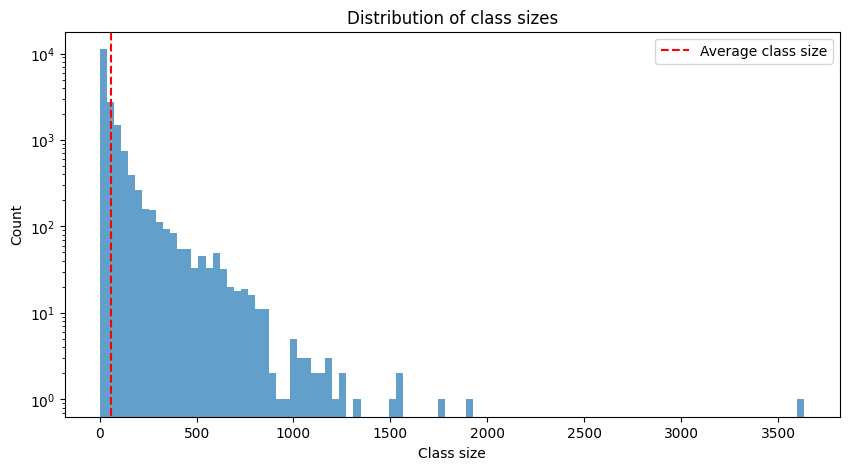

In [ ]:
n_sequences = df.shape[0]
n_classes = df["accession_no"].nunique()
class_sizes = df.groupby("accession_no").size().values
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(class_sizes, bins=100, alpha=0.7)
ax.set(yscale='log')
ax.vlines(n_sequences / n_classes, 0, 1e5, color='red', linestyle='--', label='Average class size')
ax.legend()
ax.set_title("Distribution of class sizes")
ax.set_xlabel("Class size")
_ = ax.set_ylabel("Count")

We can see that the classes are very imbalanced, with the modal class size being 1 (516 occurunces), and the maximum class size being 3636. We will have to compensate for this when training our model and choose performance metrics carefully.
## Input Features

In [40]:
df["sequence_length"] = df["sequence"].apply(len)
df["sequence_length"].describe()

count    1.085997e+06
mean     1.554183e+02
std      1.201359e+02
min      4.000000e+00
25%      7.600000e+01
50%      1.190000e+02
75%      1.950000e+02
max      2.037000e+03
Name: sequence_length, dtype: float64

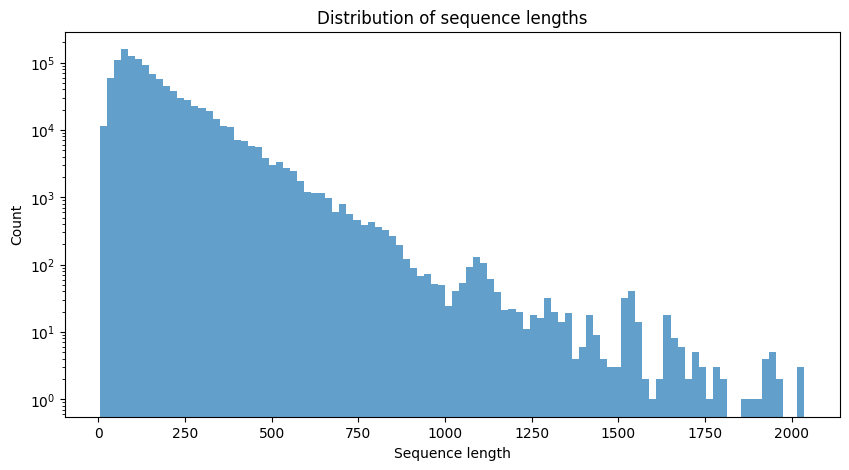

In [ ]:
sequences = df["sequence"].values
lengths = [len(seq) for seq in sequences]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(lengths, bins=100, alpha=0.7)
ax.set(yscale='log')
ax.set_title("Distribution of sequence lengths")
ax.set_xlabel("Sequence length")
_ = ax.set_ylabel("Count")

In [42]:
# get unique amino acids in the dataset and their counts
unique_amino_acids = Counter("".join(df["sequence"].values))


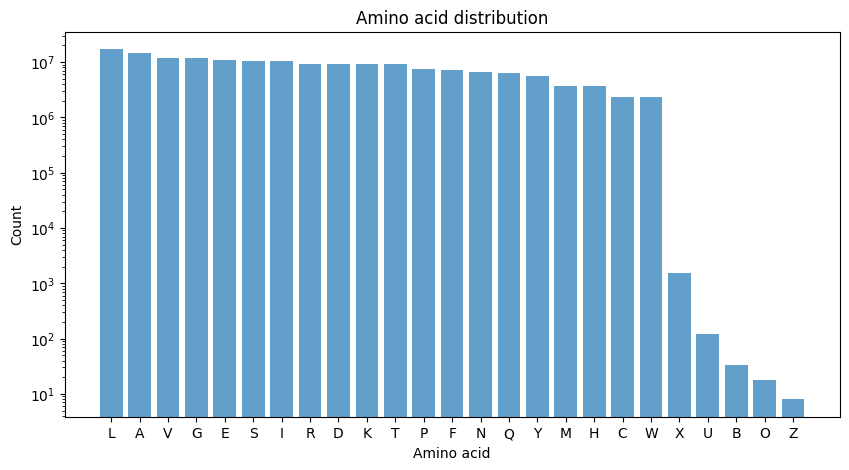

In [ ]:
# plot a bar chart of the unique amino acids and their counts sorted by count
keys, values = zip(*sorted(unique_amino_acids.items(), key=lambda x: x[1], reverse=True))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(keys, values, alpha=0.7)
ax.set_title("Amino acid distribution")
ax.set_xlabel("Amino acid")
ax.set_ylabel("Count")
_ = ax.set(yscale='log')

As discussed on the kaggle page, there are 20 very frequently arising amino acids (L-W in the above plot), and 5 much less frequently arising amino acids.

Most likely, our input vector to our model will be a matrix formed by a sequence of one hot vectors encoding each amino acid. Each one hot encoding vector will have length 25, and the sequence will have a length of >2037 to allow all possible sequences to be input into the model. Sequences which are shorter than this will be padded.

## Looking at ESM Embeddings

In [44]:
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig
from pfamformer.data_handling import load, clean_train

client = ESMC.from_pretrained("esmc_300m").to("cpu")

In [51]:
sequence = df["sequence"].values[2]
protein = ESMProtein(sequence="AAAAA")
protein_tensor = client.encode(protein)
logits_output = client.logits(
protein_tensor, LogitsConfig(sequence=True, return_embeddings=True)
)
logits_output.embeddings.numpy().flatten().shape

(6720,)

In [48]:
# take the 64 most common
grouped = df.groupby(by="accession_no").size()
nos, sizes = zip(*sorted(grouped.items(), key=lambda x: x[1], reverse=True))
top_64 = nos[:64]
df_64 = df[df["accession_no"].isin(top_64)]
# randomly select 500 from each family
df_64_small = df_64.groupby('accession_no', group_keys=False).apply(lambda x: x.sample(50))

/var/folders/z_/htd2gw213jd38_vq8kz452lw0000gp/T/ipykernel_5066/2029821126.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_64_small = df_64.groupby('accession_no', group_keys=False).apply(lambda x: x.sample(50))


In [68]:
embeddings = np.zeros((3200, 960))
for i, sequence in tqdm(enumerate(df_64_small["sequence"])):
    protein = ESMProtein(sequence=sequence)
    protein_tensor = client.encode(protein)
    logits_output = client.logits(
    protein_tensor, LogitsConfig(sequence=True, return_embeddings=True)
    )
    embedding = logits_output.embeddings.numpy()
    embeddings[i] = np.mean(embedding[0], axis=0)

3200it [37:53,  1.41it/s]


In [137]:
embeddings2 = np.load("../data/df_64_small_embeddings.npy")

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [118]:
labels = df_64_small.accession_no.values
ulabels = set(labels)
np.random.seed(0)
color_dict = {label:np.random.uniform(0,1,3) for label in ulabels}
colors = [color_dict[label] for label in labels]

In [176]:
# reduced = PCA(n_components=960).fit_transform(embeddings)
k = 3600
reduced = embeddings[:k]
results = TSNE(perplexity=5, learning_rate="auto", init="random", max_iter=5000).fit_transform(reduced)

(-188.15011672973634,
 194.64943008422853,
 -208.27726211547852,
 201.20910110473633)

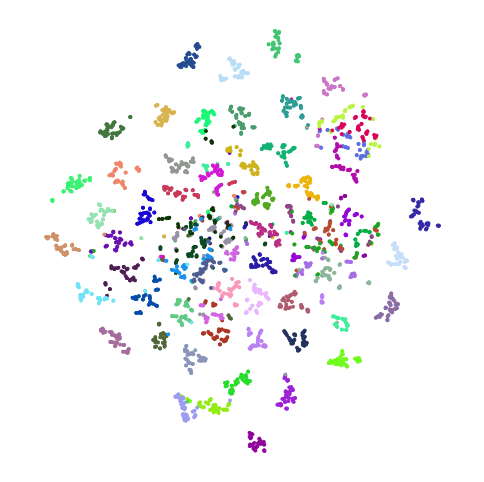

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(*results.T, c=colors[:k], s=5)
ax.axis("equal")
ax.axis("off")

We can see that the protein families are mostly grouped into tightly clustered groups based on their label.
# Training Logistic Classifier on Embeddings


In [ ]:
import torch

class LR(torch.nn.Module):

    def __init__(self, n_features, n_outputs):
        super(LR, self).__init__()
        self.lr = torch.nn.Linear(n_features, n_outputs)
        
    def forward(self, x):
        out = torch.sigmoid(self.lr(x))
        return out



In [234]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

labels = df_64_small["accession_no"].values
features = embeddings
X = torch.tensor(features, dtype=torch.float32)
classes = list(set(labels))
class_to_idx = {c: i for i, c in enumerate(classes)}
y = torch.tensor([class_to_idx[l] for l in labels], dtype=torch.long)

model = nn.Linear(960, len(classes))
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-1)

In [232]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    rec = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    df = pd.DataFrame({
        'label': labels,
        'accuracy': [acc]*len(labels),
        'precision': prec,
        'recall': rec,
        'f1': f1
    })
    return df

/var/folders/z_/htd2gw213jd38_vq8kz452lw0000gp/T/ipykernel_5066/81467312.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  average_metrics = metrics_df.groupby("epoch").apply(np.mean, axis=0)


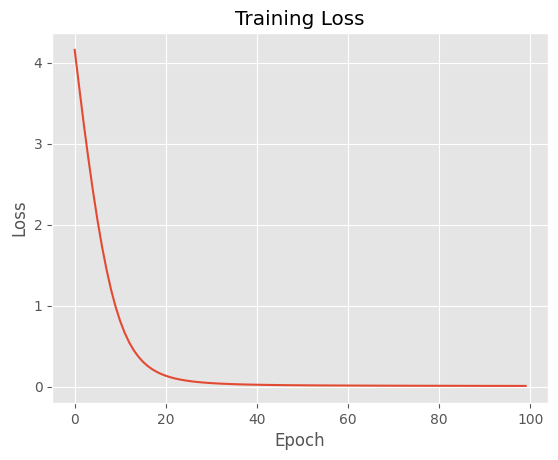

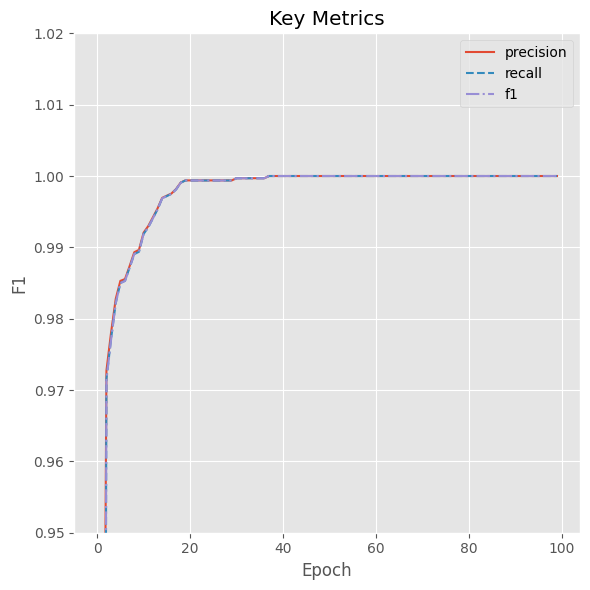

In [ ]:
losses = []
metrics = []
plt.style.use("ggplot")
for epoch in range(100):
    optimizer.zero_grad()
    logits = model(X)
    loss = loss_fn(logits, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    preds = torch.argmax(logits, dim=1).cpu().numpy()
    y_true = y.cpu().numpy()
    m_df = compute_metrics(y_true, preds, list(range(len(classes))))
    m_df['epoch'] = epoch
    metrics.append(m_df)

metrics_df = pd.concat(metrics, ignore_index=True)

fig, ax = plt.subplots()
ax.plot(losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')

fig, ax = plt.subplots(figsize=(6,6))
average_metrics = metrics_df.groupby("epoch").apply(np.mean, axis=0)
linestyles = ["-","--","-."]
for i, metric in enumerate(['precision', 'recall', 'f1']):
    ax.plot(
        average_metrics['epoch'],
        average_metrics[metric],
        linestyle=linestyles[i],
        label=metric
    )
ax.set(ylim=(0.95,1.02))
ax.set_xlabel('Epoch')
ax.set_ylabel(metric.capitalize())
ax.set_title(f'Key Metrics')
ax.legend()
plt.tight_layout()